In [1]:
import pandas as pd
import matplotlib.pyplot as plt #kontrol, çizgi kalınlığı vb
import seaborn as sns #sütun ve satır ilişkisini çizer

df = pd.read_csv('StudentPerformanceFactors.csv')

In [2]:
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [3]:
print(df.isnull().sum())
#sadece df.isnull() dersek binlerce True False çıkar ama .sum() eklersek her sütundaki True değerini 1 sayarak toplar, böylece hangi sütunda toplam kaç eksik var onu görürüz

Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64


In [4]:
before = df.shape[0]
df_clear = df.dropna() #boş satırları sileriz
after = df_clear.shape[0]
print(before - after, " tane satır silindi. kalan satır sayısı ", after)
print(df_clear.isnull().sum())

229  tane satır silindi. kalan satır sayısı  6378
Hours_Studied                 0
Attendance                    0
Parental_Involvement          0
Access_to_Resources           0
Extracurricular_Activities    0
Sleep_Hours                   0
Previous_Scores               0
Motivation_Level              0
Internet_Access               0
Tutoring_Sessions             0
Family_Income                 0
Teacher_Quality               0
School_Type                   0
Peer_Influence                0
Physical_Activity             0
Learning_Disabilities         0
Parental_Education_Level      0
Distance_from_Home            0
Gender                        0
Exam_Score                    0
dtype: int64


In [5]:
mapping = {'Low' : 1, 'Medium' : 2, 'High' : 3} #ml stringlerle çalışmaz o yüzden stringleri integera çevirelim (female-male, public-private için gerekli değil)
df_clear[ 'Parental_Involvement' ] = df_clear[ 'Parental_Involvement' ].map(mapping)
df_clear[ 'Access_to_Resources' ] = df_clear[ 'Access_to_Resources' ].map(mapping)
df_clear[ 'Motivation_Level' ] = df_clear[ 'Motivation_Level' ].map(mapping)
df_clear[ 'Family_Income' ] = df_clear[ 'Family_Income' ].map(mapping)
df_clear[ 'Teacher_Quality' ] = df_clear[ 'Teacher_Quality' ].map(mapping)

/tmp/ipykernel_1694/467796837.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clear[ 'Parental_Involvement' ] = df_clear[ 'Parental_Involvement' ].map(mapping)
/tmp/ipykernel_1694/467796837.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clear[ 'Access_to_Resources' ] = df_clear[ 'Access_to_Resources' ].map(mapping)
/tmp/ipykernel_1694/467796837.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value inst

In [6]:
print(df_clear[['Hours_Studied', 'Attendance', 'Exam_Score', 'Physical_Activity', 'Previous_Scores', 'Sleep_Hours', 'Tutoring_Sessions']].dtypes)

Hours_Studied        int64
Attendance           int64
Exam_Score           int64
Physical_Activity    int64
Previous_Scores      int64
Sleep_Hours          int64
Tutoring_Sessions    int64
dtype: object


In [7]:
df_final = pd.get_dummies(df_clear, drop_first=True)
df_final.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Sleep_Hours,Previous_Scores,Motivation_Level,Tutoring_Sessions,Family_Income,Teacher_Quality,...,Internet_Access_Yes,School_Type_Public,Peer_Influence_Neutral,Peer_Influence_Positive,Learning_Disabilities_Yes,Parental_Education_Level_High School,Parental_Education_Level_Postgraduate,Distance_from_Home_Moderate,Distance_from_Home_Near,Gender_Male
0,23,84,1,3,7,73,1,0,1,2,...,True,True,False,True,False,True,False,False,True,True
1,19,64,1,2,8,59,1,2,2,2,...,True,True,False,False,False,False,False,True,False,False
2,24,98,2,2,7,91,2,2,2,2,...,True,True,True,False,False,False,True,False,True,True
3,29,89,1,2,8,98,2,1,2,2,...,True,True,False,False,False,True,False,True,False,True
4,19,92,2,2,6,65,2,3,2,3,...,True,True,True,False,False,False,False,False,True,False


In [8]:
print(df_final.info())

<class 'pandas.core.frame.DataFrame'>
Index: 6378 entries, 0 to 6606
Data columns (total 23 columns):
 #   Column                                 Non-Null Count  Dtype
---  ------                                 --------------  -----
 0   Hours_Studied                          6378 non-null   int64
 1   Attendance                             6378 non-null   int64
 2   Parental_Involvement                   6378 non-null   int64
 3   Access_to_Resources                    6378 non-null   int64
 4   Sleep_Hours                            6378 non-null   int64
 5   Previous_Scores                        6378 non-null   int64
 6   Motivation_Level                       6378 non-null   int64
 7   Tutoring_Sessions                      6378 non-null   int64
 8   Family_Income                          6378 non-null   int64
 9   Teacher_Quality                        6378 non-null   int64
 10  Physical_Activity                      6378 non-null   int64
 11  Exam_Score                         

In [9]:
#hedefimiz Exam_Score o yüzden hedefi (y) ve özellikleri (x) ayırırız
y = df_final[ 'Exam_Score'] # axis = 0 yukarıdan aşağı
x = df_final.drop('Exam_Score', axis = 1) # axis = 1 soldan sağa, yani burada diyoruz ki tabloya bak, 'Exam_Score' isimli SÜTUNU bul ve onu yukarıdan aşağıya komple kesip at.
print(y.head())
print(x.head())

0    67
1    61
2    74
3    71
4    70
Name: Exam_Score, dtype: int64
   Hours_Studied  Attendance  Parental_Involvement  Access_to_Resources  \
0             23          84                     1                    3   
1             19          64                     1                    2   
2             24          98                     2                    2   
3             29          89                     1                    2   
4             19          92                     2                    2   

   Sleep_Hours  Previous_Scores  Motivation_Level  Tutoring_Sessions  \
0            7               73                 1                  0   
1            8               59                 1                  2   
2            7               91                 2                  2   
3            8               98                 2                  1   
4            6               65                 2                  3   

   Family_Income  Teacher_Quality  ...  Inter

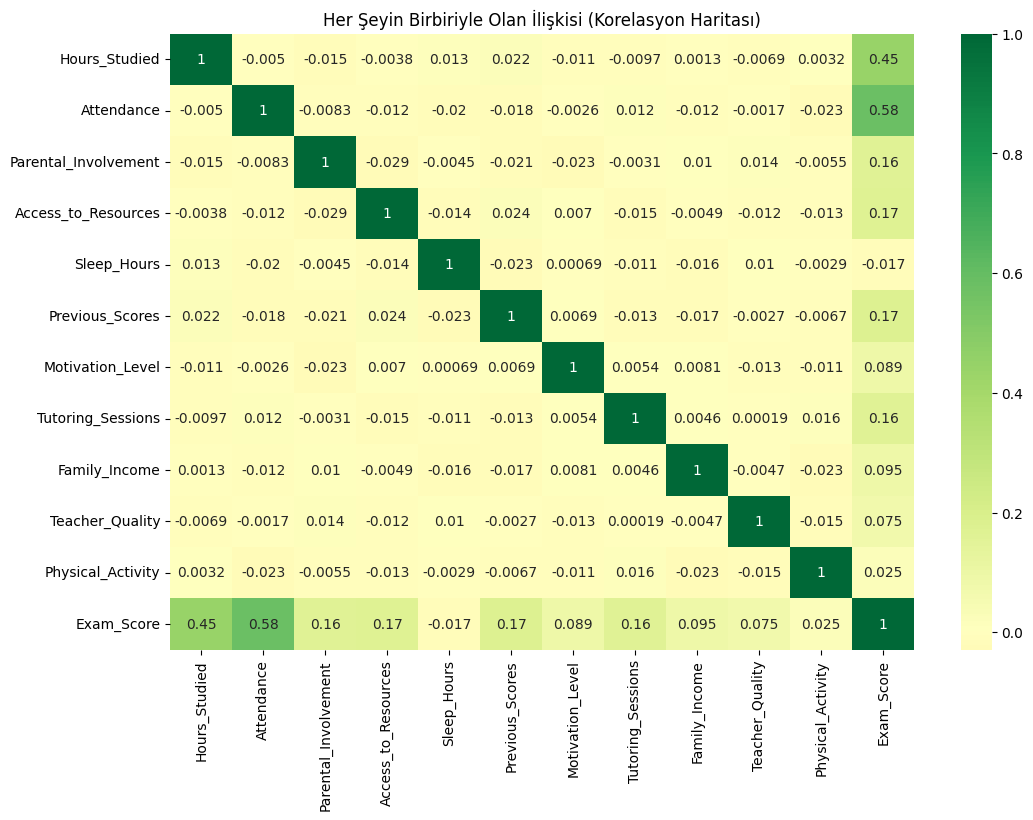

In [10]:
plt.figure(figsize=(12, 8))
# Sadece sayısal sütunları alalım
numeric_df = df_clear.select_dtypes(include=['int64', 'float64'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='RdYlGn', center=0)
plt.title('Her Şeyin Birbiriyle Olan İlişkisi (Korelasyon Haritası)')
plt.show() #pozitif kolerasyon (0 ile 1) doğru oran, zayıf kolerasyon (0a yakın) neredeyse etkisiz, negatif kolerasyon (0 ile -1) ters orantı

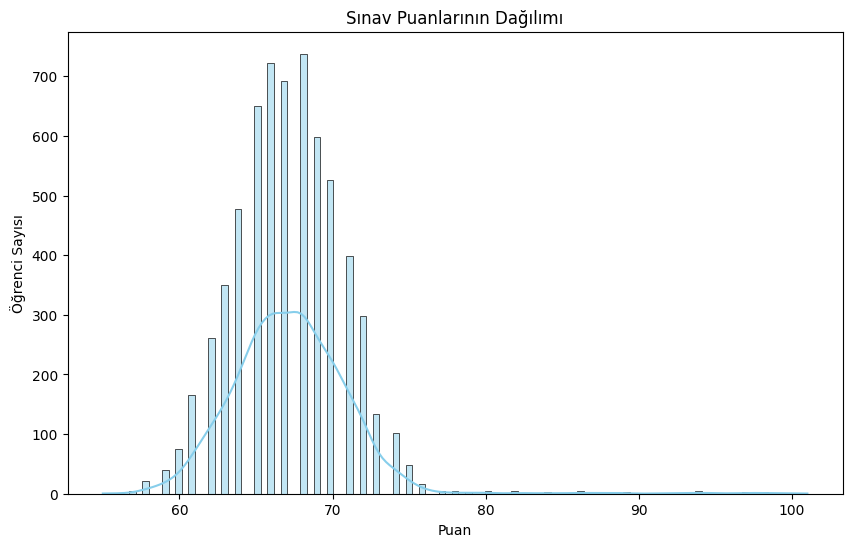

In [11]:
plt.figure(figsize=(10, 6)) #size of the graph 10 : genişlik, 6 : yüksekliği
sns.histplot(df_clear['Exam_Score'], kde=True, color='skyblue') #sadece bir sütuna bakar
plt.title('Sınav Puanlarının Dağılımı')
plt.xlabel('Puan')
plt.ylabel('Öğrenci Sayısı')
plt.show()

çubuklar, yani histogram grafiğimizden not yoğunluğunun 60 ve 75 arasında ve yaklaşık 68 puan civarında zirve yapmış olduğunu görüyoruz

yoğunluk tahmin çizgisi (kernel density estimate), histogram grafiğini yumuşatarak verinin genel dağılım trendini görmemizi sağlar. histogramdan daha alçakta olmasının sebebi çubuklar "kişi sayısını" sayarken, bu çizgi "olasılığı" hesaplar.

veri sağa doğru uzuyor ama kalabalık sol tarafta. bu da bize sınavın pek de "kolay" olmadığını, yüksek not almanın zor olduğunu gösteriyor.

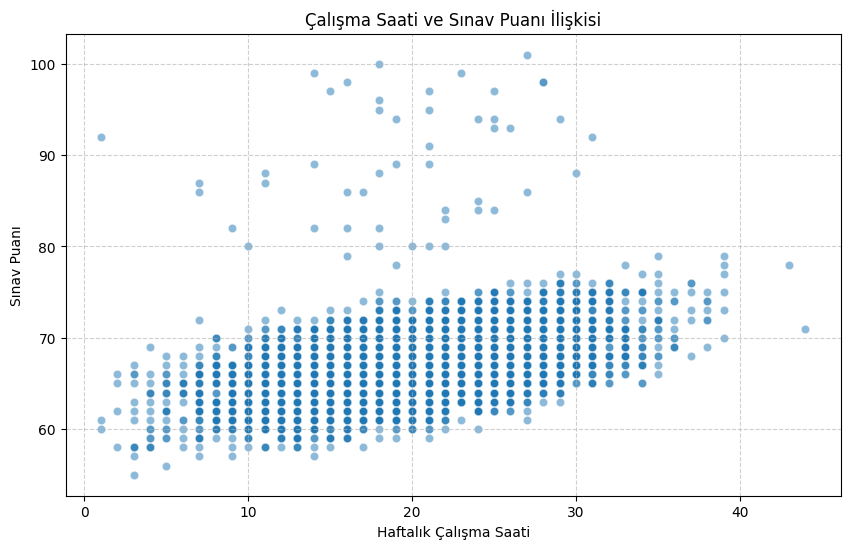

In [12]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Hours_Studied', y='Exam_Score', data=df_clear, alpha=0.5)
#alpha şeffaflık 0.5 yarı şeffaf 0 tamamen şeffaf 1 tamamen mat
#iki farklı sayısal sütuna bakar
plt.title('Çalışma Saati ve Sınav Puanı İlişkisi')
plt.xlabel('Haftalık Çalışma Saati')
plt.ylabel('Sınav Puanı')
plt.grid(True, linestyle='--', alpha=0.6) #arka plana yardımcı çizgiler ekler
plt.show()

bu bir scatter plot (serpilme diagramı)
grafiğe uzaktan baktığımızda noktaların genel olarak soldan sağa doğru yukarı tırmandığını görebiliriz. bu, istatistikte pozitif korelasyon olarak adlandırılır.

sağ tarafta, 40 saate yakın çalışmasına rağmen hala 70 bandında kalanlar var. bu da bize "çok çalışmanın her zaman en yüksek puanı garanti etmediğini" söyler.
yani puanı belirleyen tek şey "çalışma saati" değil; zeka, uyku, sınav stresi gibi başka faktörler de devrede.

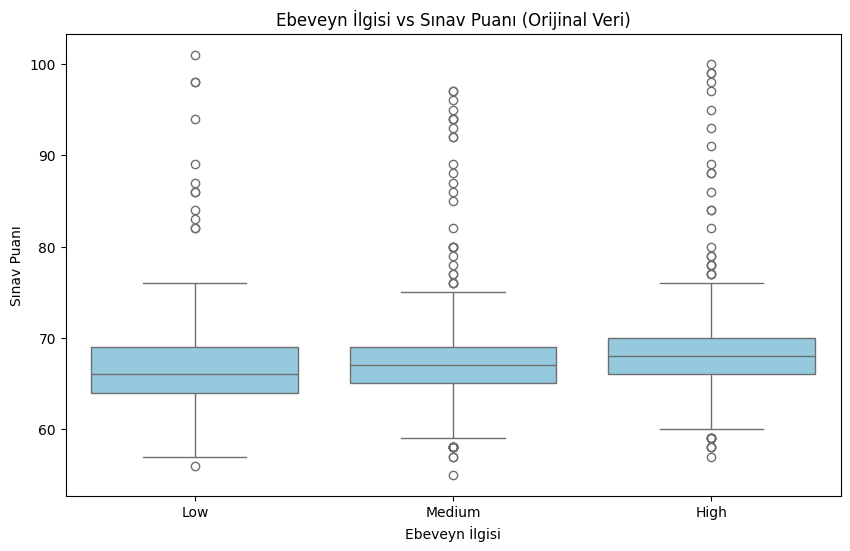

In [13]:
# 1. Adım: Veriyi en baştan tertemiz yükleyelim (Değişkenlerin orijinal kelime halleri gelsin)
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df_fresh = pd.read_csv('StudentPerformanceFactors.csv') # Dosya adını kontrol et
df_fresh.columns = df_fresh.columns.str.strip() # Sütun isimlerindeki boşlukları temizle
df_fresh = df_fresh.dropna() # Boş satırları at

# 2. Adım: Boxplot'u bu 'fresh' veriyle çizelim
plt.figure(figsize=(10, 6))

# Renklendirme hatası almamak için en güvenli yolu kullanıyoruz
sns.boxplot(x='Parental_Involvement',
            y='Exam_Score',
            data=df_fresh,
            order=['Low', 'Medium', 'High'],
            color='skyblue') # Tek renk vererek karmaşayı önledik

plt.title('Ebeveyn İlgisi vs Sınav Puanı (Orijinal Veri)')
plt.ylabel('Sınav Puanı')
plt.xlabel('Ebeveyn İlgisi')
plt.show()

box plot
low (düşük): medyan yaklaşık 66 civarında.

medium (orta): medyan yaklaşık 67 seviyesinde.

high (yüksek): medyan yaklaşık 68 civarında.

ebeveyn ilgisi arttıkça başarı artmış

kutuların genişliği (alt ve üst sınırları), verilerin %50'sinin bulunduğu alanı gösterir.
high (yüksek) grubunun kutusu, diğerlerine göre bir tık daha yukarıda konumlanmış durumda. bu, ebeveyn ilgisi yüksek olan çocukların puan tabanının biraz daha yukarıya çekildiğini gösteriyor.

aykırı değerler: high (yüksek) grubunun kutusu, diğerlerine göre bir tık daha yukarıda konumlanmış durumda. bu, ebeveyn ilgisi yüksek olan çocukların puan tabanının biraz daha yukarıya çekildiğini gösteriyor.


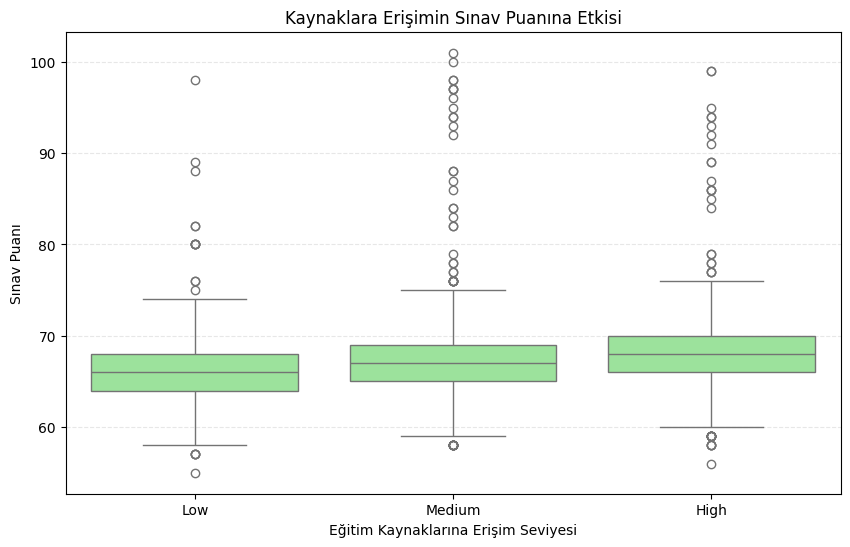

In [14]:
plt.figure(figsize=(10, 6))

# Renk hatasını önlemek için yine 'color' parametresiyle ilerliyoruz
# 'lightgreen' veya 'salmon' gibi istediğin bir rengi seçebilirsin
sns.boxplot(x='Access_to_Resources',
            y='Exam_Score',
            data=df_fresh,
            order=['Low', 'Medium', 'High'],
            color='lightgreen')

plt.title('Kaynaklara Erişimin Sınav Puanına Etkisi')
plt.ylabel('Sınav Puanı')
plt.xlabel('Eğitim Kaynaklarına Erişim Seviyesi')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

low (düşük): medyan yaklaşık 66 civarında.

medium (orta): medyan yaklaşık 67 seviyesinde.

high (yüksek): medyan yaklaşık 68 civarında.

kaynak arttıkça başarı artmış

aykırı değerler: kaynak erişimi "low" (düşük) olan grupta bile 100 tam puana yaklaşan (yaklaşık 98 puan) bir öğrenci var.


orta ("medium") gruptaki aykırı değerlerin (başarılı öğrencilerin) sayısı, "high" grubundan daha yoğun görünüyor. bu, çok fazla kaynağa sahip olmanın tek başına "en iyisi" olmayı garantilemediğini, orta düzey kaynağın da zirveye çıkmak için yeterli olabileceğini gösteriyor.


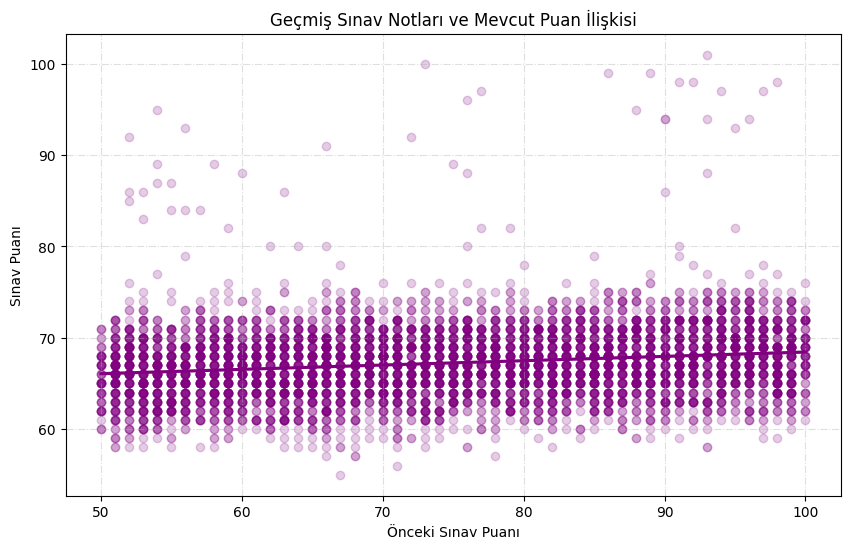

In [15]:
plt.figure(figsize=(10, 6))
sns.regplot(x='Previous_Scores', y='Exam_Score', data=df_clear, scatter_kws={'alpha':0.2}, color='purple')
plt.title('Geçmiş Sınav Notları ve Mevcut Puan İlişkisi')
plt.xlabel('Önceki Sınav Puanı')
plt.ylabel('Sınav Puanı')
plt.grid(True, linestyle='-.', alpha=0.4)
plt.show()

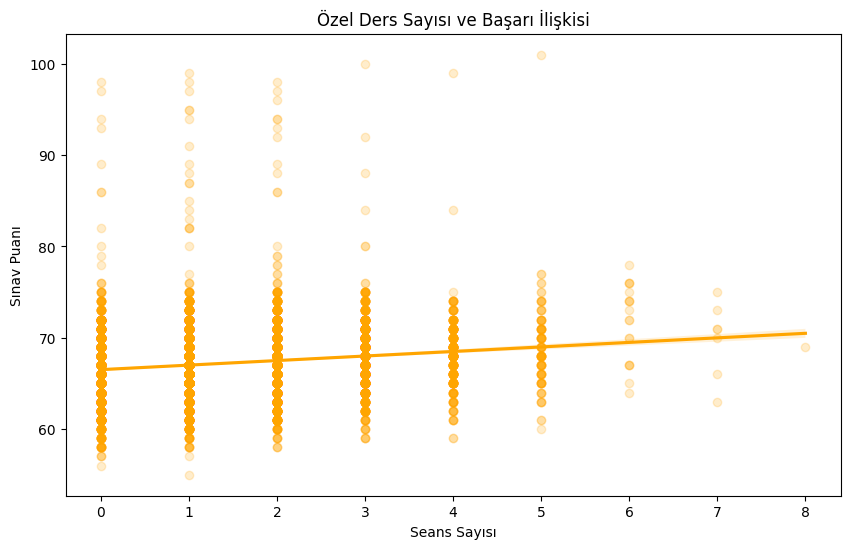

In [16]:
plt.figure(figsize=(10, 6))
sns.regplot(x='Tutoring_Sessions', y='Exam_Score', data=df_clear, scatter_kws={'alpha':0.2}, color='orange')
plt.title('Özel Ders Sayısı ve Başarı İlişkisi')
plt.xlabel('Seans Sayısı')
plt.ylabel('Sınav Puanı')
plt.show()

Lineer Regresyon: Eğer ilişki doğrusal ise en basit ve hızlı yöntemdir.

Karar Ağaçları (Decision Trees): Kategorik verilerle (Low/Medium/High) çok iyi çalışır.

Random Forest: Verideki "aykırı değerleri" (grafikteki o uç noktaları) daha iyi yönetebilir.

Lineer Regresyon: Eğer çizdiğimiz o regplot grafiklerindeki noktalar düz bir çizgiye çok yakın dizildiyse bu model genellikle yeterli olur. Basit ve hızlıdır.

Karar Ağaçları (Decision Trees): Eğer veride "Eğer ebeveyn ilgisi High ise VE çalışma saati 10'dan büyükse puanı 80 yap" gibi net kırılmalar varsa bu model çok başarılıdır.

Random Forest: Veride çok fazla gürültü veya kafa karıştırıcı uç nokta varsa kullanılır. Yüzlerce küçük karar ağacını birleştirip "ortak akıl" yürüttüğü için hata payı genellikle en düşük olandır.

In [17]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Veriyi Yükle ve Temizle
df_final = pd.read_csv('StudentPerformanceFactors.csv')
df_final = df_final.dropna()
df_final.columns = df_final.columns.str.strip()

# 2. Sayısallaştırma (Kategorik verileri 0 ve 1 yapma)
df_numeric = pd.get_dummies(df_final, drop_first=True)

# 3. Hedef ve Özellikleri Ayır
y = df_numeric['Exam_Score']
X = df_numeric.drop('Exam_Score', axis=1)

# 4. Veriyi Böl (Hata aldığın X_train burada tanımlanıyor)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Modelleri Tanımla
modeller = {
    "Lineer Regresyon": LinearRegression(),
    "Karar Ağacı": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42)
}

# 6. Yarışmayı Başlat
print("Model Sonuçları Karşılaştırılıyor...\n")
for isim, model in modeller.items():
    model.fit(X_train, y_train) # Eğit
    y_pred = model.predict(X_test) # Tahmin et

    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f"--- {isim} ---")
    print(f"Ortalama Hata (MAE): {mae:.2f} puan") # MAE (Ortalama Mutlak Hata)
    print(f"Başarı Oranı (R2): %{r2*100:.2f}\n") # R2 Score (Belirlilik Katsayısı)

    #Lineer Regresyon en iyi model çıktı çünkü MAE'si en düşük (0.49), R2'si en yüksek (%73.14)

Model Sonuçları Karşılaştırılıyor...

--- Lineer Regresyon ---
Ortalama Hata (MAE): 0.49 puan
Başarı Oranı (R2): %73.14

--- Karar Ağacı ---
Ortalama Hata (MAE): 1.85 puan
Başarı Oranı (R2): %16.55

--- Random Forest ---
Ortalama Hata (MAE): 1.25 puan
Başarı Oranı (R2): %61.09



In [18]:
# Şampiyon modeli (Lineer Regresyon) tekrar tanımlayalım ve eğitelim
final_model = LinearRegression()
final_model.fit(X_train, y_train)

# Bir örnek tahmin yapalım (Bu değerleri sen de değiştirebilirsin!)
# Not: Buradaki X_test.iloc[0] ilk öğrencinin verilerini temsil eder
ornegin_verisi = X_test.iloc[[0]]
tahmin = final_model.predict(ornegin_verisi)

print(f"Öğrencinin Gerçek Puanı: {y_test.iloc[0]}")
print(f"Modelin Tahmini: {tahmin[0]:.2f}")

Öğrencinin Gerçek Puanı: 74
Modelin Tahmini: 73.97


In [19]:
#linear regression kullanarak yeni bir tahmin yapalım
import numpy as np

#önce sütun isimlerini görelim ki neye ne değer vereceğimizi bilelim
#print(X.columns) #bunu çalıştırıp hangi sütunlar olduğunu görebilirsin

# ÖRNEK: rastgele bir öğrenci verisi (test setinden birini çekelim)
index = 10 # 10. sıradaki öğrenciyi seçtik
ogrenci_verisi = X_test.iloc[[index]] #iloc : index location
#X_test.iloc[10] 11. sıradaki (saymaya 0'dan başladığımız için) öğrenciyi getirir.
gercek_puan = y_test.iloc[index]
tahmin_puan = modeller["Lineer Regresyon"].predict(ogrenci_verisi)

print(f"--- 10. Sıradaki Öğrenci Analizi ---")
print(f"Gerçek Puan: {gercek_puan}")
print(f"Modelin Tahmini: {tahmin_puan[0]:.2f}")
print(f"Sapma Payı: {abs(gercek_puan - tahmin_puan[0]):.2f} puan")

--- 10. Sıradaki Öğrenci Analizi ---
Gerçek Puan: 62
Modelin Tahmini: 62.55
Sapma Payı: 0.55 puan


--- Hangi Faktör Puanı Ne Kadar Etkiliyor? ---
                                   Faktör  Etki Miktarı
20                Peer_Influence_Positive      1.014880
13                    Internet_Access_Yes      0.900608
25                Distance_from_Home_Near      0.841829
10         Extracurricular_Activities_Yes      0.566723
19                 Peer_Influence_Neutral      0.561867
23  Parental_Education_Level_Postgraduate      0.521576
4                       Tutoring_Sessions      0.482777
24            Distance_from_Home_Moderate      0.304964
0                           Hours_Studied      0.295834
5                       Physical_Activity      0.200224
1                              Attendance      0.198689
18                     School_Type_Public      0.048959
3                         Previous_Scores      0.048514
26                            Gender_Male     -0.010802
2                             Sleep_Hours     -0.012829
22   Parental_Education_Level_High School     -0.476205
1

/tmp/ipykernel_1694/4159278952.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Etki Miktarı', y='Faktör', data=katsayilar, palette='RdYlGn')


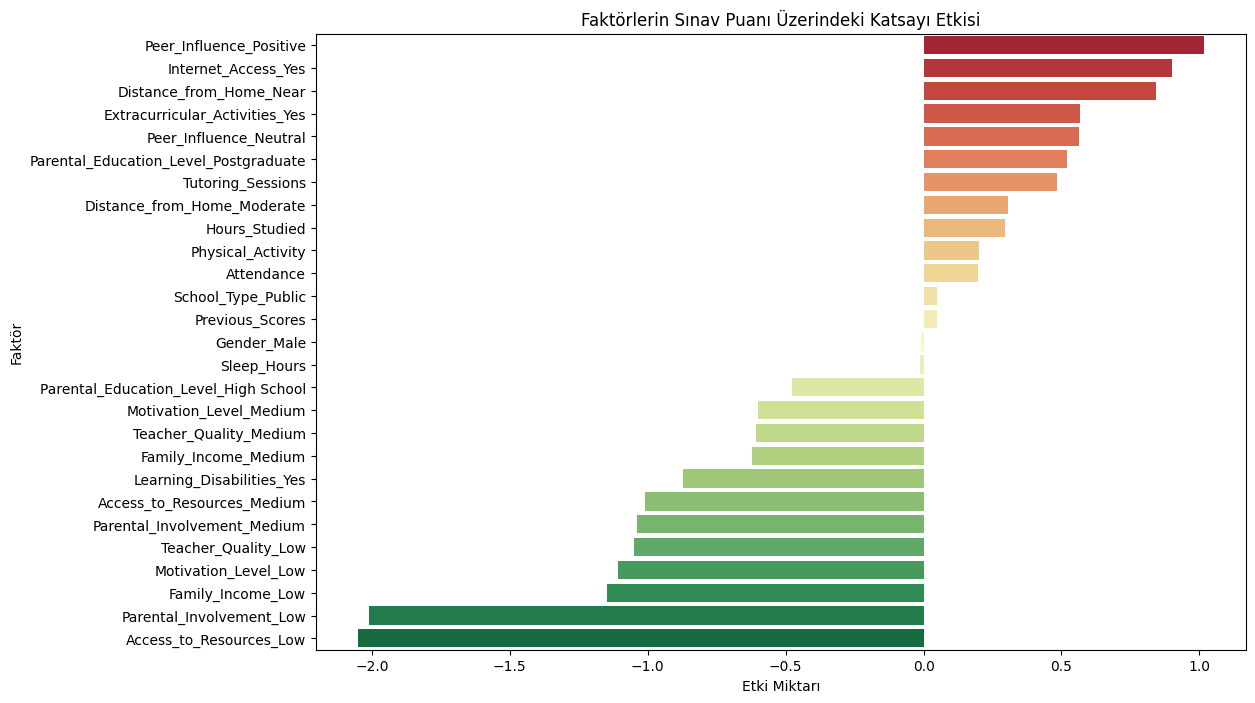

In [20]:
#modelin katsayılarını (importance) bir tabloya dönüştürelim
katsayilar = pd.DataFrame({
    'Faktör': X.columns,
    'Etki Miktarı': modeller["Lineer Regresyon"].coef_
}).sort_values(by='Etki Miktarı', ascending=False)

print("--- Hangi Faktör Puanı Ne Kadar Etkiliyor? ---")
print(katsayilar)

#görselleştirelim
plt.figure(figsize=(12, 8))
sns.barplot(x='Etki Miktarı', y='Faktör', data=katsayilar, palette='RdYlGn')
plt.title('Faktörlerin Sınav Puanı Üzerindeki Katsayı Etkisi')
plt.show()

#veriler + ise not artıyor - ise azalıyor mesela internet accessi neredeyse 1 puan arttırıyor

In [21]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive
